<a href="https://colab.research.google.com/github/Nguyen-Quoc-An/TH_DeepLearning/blob/main/Lab4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CNN


In [43]:
# Đọc dữ liệu MNIST
mnist_train ='/content/sample_data/mnist_train_small.csv'
mnist_test ='/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [44]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [45]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)


print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


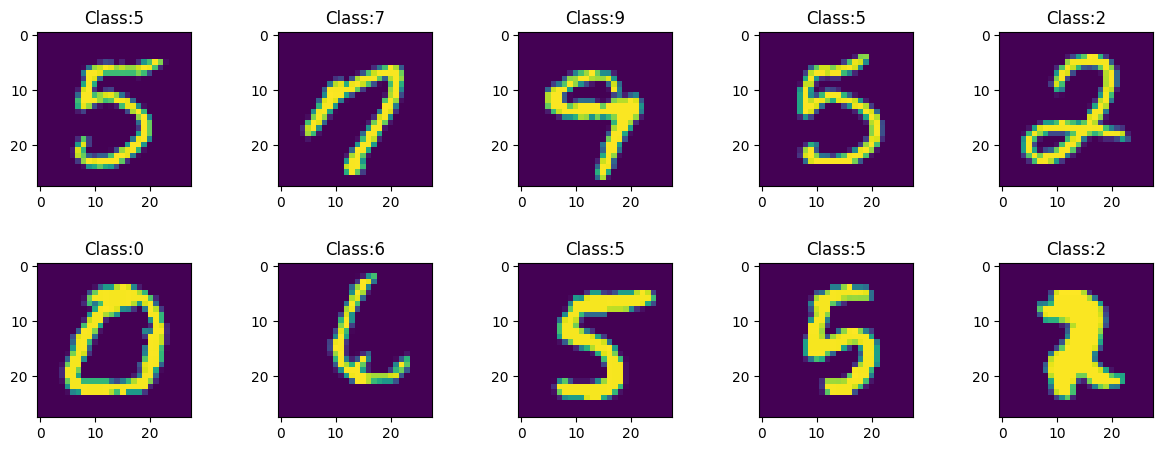

In [46]:
# Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [47]:
# Chuyển giá trị nhãn thành one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [48]:
# Xây dựng mô hình
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation="softmax"))
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Biên dịch và Huấn luyện mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.8463 - loss: 0.5867 - val_accuracy: 0.9425 - val_loss: 0.1997
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.9576 - loss: 0.1454 - val_accuracy: 0.9635 - val_loss: 0.1316
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.9708 - loss: 0.0979 - val_accuracy: 0.9680 - val_loss: 0.1016
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.9775 - loss: 0.0733 - val_accuracy: 0.9755 - val_loss: 0.0854
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.9814 - loss: 0.0600 - val_accuracy: 0.9700 - val_loss: 0.1014
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.9839 - loss: 0.0506 - val_accuracy: 0.9760 - val_loss: 0.0772
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.9852 - loss: 0.0447 - val_accuracy: 0.9780 - val_loss: 0.0825
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.9864 - loss: 0.0411 - 

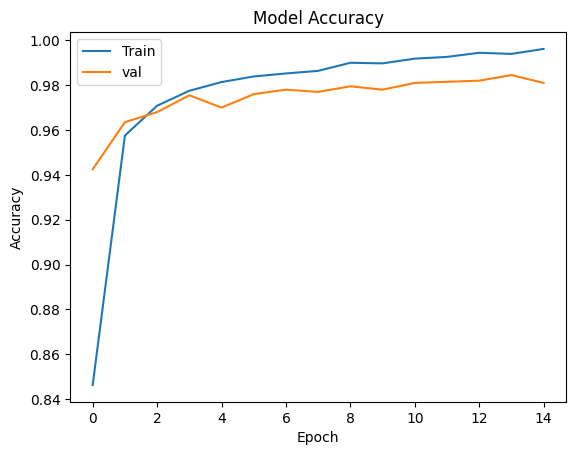

In [50]:
# Đánh giá Accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'val'], loc='upper left')
plt.show()

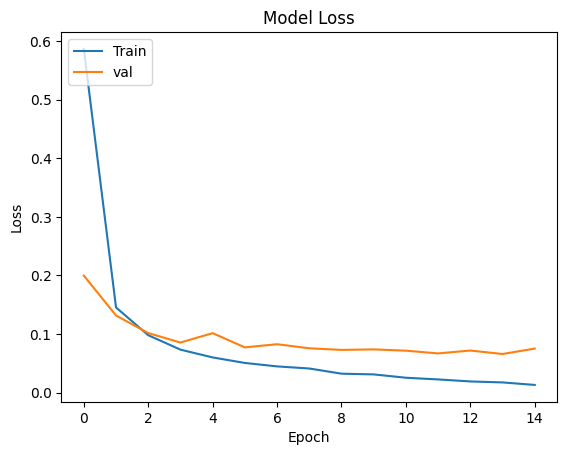

In [51]:
# Đánh giá Loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'val'], loc='upper left')
plt.show()

In [52]:
# Đánh giá trên tập test
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 7ms/step - accuracy: 0.9830 - loss: 0.0573
Test loss: 0.057255249470472336
Test accuracy: 0.9829983115196228


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
[[1.52103075e-05 2.17649576e-05 9.99962926e-01 1.07063602e-09
  6.37260202e-19 2.22357287e-15 1.89856237e-08 2.46401397e-15
  3.45985440e-09 8.14132420e-20]]
2 2


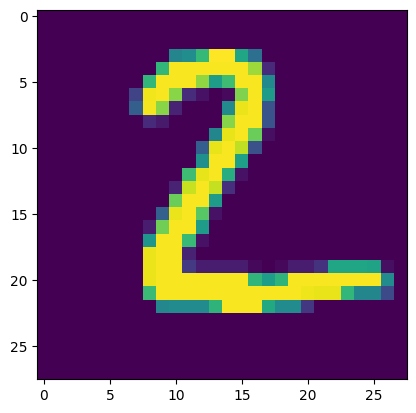

In [53]:
# Dự báo nhãn cho ảnh
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))

plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
[[7.0511369e-08 9.9992287e-01 4.6546579e-06 6.0001426e-08 6.1880077e-05
  9.6564001e-08 2.0744768e-07 3.7005948e-06 6.3214061e-06 1.6709690e-08]]
1 1


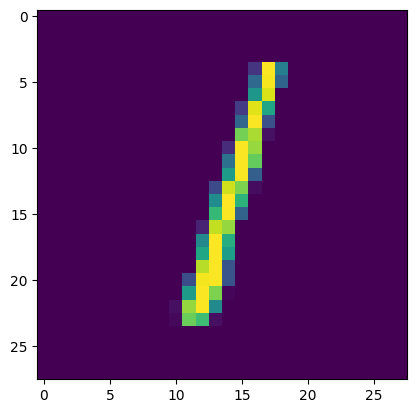

In [54]:
# Lưu tham số mô hình CNN
model.save_weights('cnn.weights.h5')
# Nạp lại mô hình và tham số
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')
predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))

plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()


#BÀI TẬP CNN

In [58]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# --- PHẦN BỔ SUNG: XÂY DỰNG MẠNG CNN ---
model_cifar = models.Sequential([
    # Khối tích chập 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Khối tích chập 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Khối tích chập 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Làm phẳng dữ liệu và đưa qua mạng nơ-ron dày đặc (Dense)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10) # Lớp Output có 10 nơ-ron tương ứng với 10 nhãn
])

# --- PHẦN BỔ SUNG: BIÊN DỊCH VÀ HUẤN LUYỆN ---
model_cifar.compile(
    optimizer='adam',
    # Dùng SparseCategoricalCrossentropy vì nhãn đang ở dạng số nguyên (0-9)
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\n--- Bắt đầu huấn luyện mô hình CIFAR-10 ---")
history = model_cifar.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

# Đánh giá mô hình trên tập test
test_loss, test_acc = model_cifar.evaluate(test_images,  test_labels, verbose=2)
print(f"\nĐộ chính xác trên tập kiểm tra: {test_acc * 100:.2f}%")

# (Tùy chọn) Lưu mô hình lại để dùng cho Câu 5 (Web Flask)
model_cifar.save('cifar10_cnn_model.h5')


--- Bắt đầu huấn luyện mô hình CIFAR-10 ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 44ms/step - accuracy: 0.4467 - loss: 1.5139 - val_accuracy: 0.5221 - val_loss: 1.2980
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.5854 - loss: 1.1665 - val_accuracy: 0.6174 - val_loss: 1.0855
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6364 - loss: 1.0311 - val_accuracy: 0.6497 - val_loss: 0.9940
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.6741 - loss: 0.9318 - val_accuracy: 0.6691 - val_loss: 0.9495
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.6983 - loss: 0.8598 - val_accuracy: 0.6728 - val_loss: 0.9438
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7137 - loss: 0.8097 - val_accuracy: 0.6915 - val_loss: 0.8940
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7307 - loss: 0.7630 - val_accuracy: 0.6903 - val_loss: 0.8981
Epoch 8/10
1563/1563 ━━━━━━━━━━


Độ chính xác trên tập kiểm tra: 70.24%
